<a href="https://colab.research.google.com/github/Winicius-dos-Passos/previsao-ur-vmd-bilstm/blob/main/VMD_BiLSTM_UR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Imports das bibliotecas
!pip install vmdpy tensorflow scikit-learn tqdm joblib -q

In [ ]:
import os
import gc
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
from tqdm import tqdm
from joblib import Parallel, delayed

import tensorflow as tf
from tensorflow.keras import mixed_precision
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Bidirectional, LSTM, Dropout, Dense
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from vmdpy import VMD

warnings.filterwarnings('ignore')

# Reprodutibilidade randômica
os.environ['PYTHONHASHSEED'] = '0'
os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['TF_CUDNN_DETERMINISTIC'] = '1'

# Sementes globais
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

tf.config.experimental.enable_op_determinism()

# Configuração de Mixed Precision
try:
    policy = mixed_precision.Policy('mixed_float16')
    mixed_precision.set_global_policy(policy)
    print('Mixed Precision ativado (GPU otimizada).')
except Exception as e:
    print('Mixed Precision não ativado (Rodando em float32).')

Mixed Precision ativado (GPU otimizada).


In [ ]:
# Carregamento dos dados
url_df = 'https://docs.google.com/spreadsheets/d/1MRqHSHxVjynI_0OFkbT18MiPGZ6p0t7b/export?format=xlsx'
df = pd.read_excel(url_df)
df['Data'] = pd.to_datetime(df['Data'], dayfirst=True)
df = df.drop(columns=['Qualidade_dado', 'Cidade', 'Chuva (mm)'])
display(df)

,Data,Tmax (°C),Tmin (°C),UR (%),U2 (m/s),Rs (MJ/m²d),Pres (kPa)
0,2007-01-01,23.90,17.70,83.50,2.483333,10.7926,90.290
1,2007-01-01,23.60,17.90,81.00,3.162500,12.9870,91.150
2,2007-01-01,22.00,16.20,85.00,4.050000,13.1611,88.040
3,2007-01-01,26.00,18.40,81.50,2.112500,15.9923,92.250
4,2007-01-02,25.50,18.80,82.50,1.550000,12.1713,90.235
...,...,...,...,...,...,...,...
34327,2023-12-31,22.20,16.20,82.50,2.629167,12.5924,91.340
34328,2023-12-31,24.70,14.30,64.50,2.358333,21.8447,88.170
34329,2023-12-31,27.67,17.22,73.28,0.930000,0.0000,92.010
34330,2023-12-31,28.30,16.00,71.00,2.195833,28.6827,91.390


In [ ]:
# Configuração explícita de threads (reduz variação numérica)
tf.config.threading.set_intra_op_parallelism_threads(1)
tf.config.threading.set_inter_op_parallelism_threads(1)

# Funções Auxiliares
def create_sequences(X, y, look_back):
  """
  Cria sequências de entrada para o modelo BiLSTM.
  """
  Xs, ys = [], []
  for i in range(len(X) - look_back):
    Xs.append(X[i:(i + look_back)])
    ys.append(y[i + look_back])
  return np.array(Xs), np.array(ys)

def avaliar_modelo(observados, estimados):
    """
    Métricas para avaliar o Modelo: RMSE, MAE, R², Willmott (d) e MBE (erro médio de vies).
    """
    obs = np.asarray(observados).reshape(-1)
    est = np.asarray(estimados).reshape(-1)
    # Índice de Concordância Willmott
    num = np.sum((est - obs) ** 2)
    den = np.sum((np.abs(est - np.mean(obs)) + np.abs(obs - np.mean(obs)))** 2)
    d = 1 - (num / den)
    # Demais métricas
    rmse = np.sqrt(mean_squared_error(obs, est))
    mae = mean_absolute_error(obs, est)
    r2 = r2_score(obs, est)
    vies = np.mean(est - obs)
    return {
        "RMSE": round(rmse, 4),
        "R²": round(r2, 4),
        "MAE": round(mae, 4),
        "Willmott": round (d, 4),
        "MBE": round(vies, 4)
      }

def calcular_janela_vmd(t, sinal, window_vmd, alpha, K, tol):
    """
    Função worker que roda em paralelo. Calcula VMD de uma janela e retorna só o último ponto.
    """
    # 1. Recorte Causal (Passado -> Presente)
    janela = sinal[t - window_vmd:t]

    # 2. Segurança contra sinal constante (evita erro de divisão por zero)
    if np.nanstd(janela) < 1e-12:
        return t, np.full(K, np.nan)

    try:
        # 3. Execução do VMD
        # u: matriz de modos. Pegamos u[:, -1] (apenas o último instante para evitar leakage)
        u, _, _ = VMD(janela, alpha, 0.0, K, 0, 1, tol)
        return t, u[:, -1]
    except Exception:
        return t, np.full(K, np.nan)

def gerar_features(df, alvo, conf_vmd, window_vmd=None, progress=True):
  """
  Gera features espectrais (VMD) e temporais (Sazonalidade) para séries temporais,
  utilizando uma abordagem de Janela Deslizante (Rolling Window) para garantir
  a integridade causal dos dados (Anti-Leakage).
  """

  df_feat = df.copy().reset_index(drop=True)
  sinal = df_feat[alvo].values.astype(float)
  n = len(sinal)

  # VMD parametros
  K = int(conf_vmd['K_vmd'])
  alpha = float(conf_vmd['alpha'])
  tol = float(conf_vmd['vmd_tol'])

  # heurística para janela causal (padrão: 2 * look_back ou 60)
  if window_vmd is None:
    lb = conf_vmd.get('look_back', 60)
    window_vmd = max(int(lb * 2), 60)

  # matriz para IMFs (n x K)
  imf_mat = np.full((n, K), np.nan)

  # Define quais índices (tempos) serão calculados
  indices_para_processar = range(window_vmd, n)

  resultados = Parallel(n_jobs=-1, backend='loky', verbose=0)(
      delayed(calcular_janela_vmd)(t, sinal, window_vmd, alpha, K, tol)
      for t in tqdm(indices_para_processar,
                    disable=not progress,
                    desc=f"VMD Causal - {alvo}",
                    ncols=120,
                    position=0,
                    leave=True)
    )

  # Montagem
  for t, imf_vals in resultados:
    imf_mat[t, :] = imf_vals

  # adicionar IMFs no DataFrame (IMF_1 ... IMF_K)
  for k in range(K):
    df_feat[f'IMF_{k+1}'] = imf_mat[:, k]

  # Sazonalidade Anual
  df_feat['dia_ano'] = df_feat['Data'].dt.day_of_year
  df_feat['sin_ano'] = np.sin(2 * np.pi * df_feat['dia_ano'] / 365.25)
  df_feat['cos_ano'] = np.cos(2 * np.pi * df_feat['dia_ano'] / 365.25)

  # Limpeza Final
  df_feat = df_feat.iloc[window_vmd:].reset_index(drop=True)
  df_feat = df_feat.dropna().reset_index(drop=True)

  # Remover colunas auxiliares
  return df_feat.drop(columns=['Data','dia_ano'])

In [ ]:
# Configurações e variavéis alvo

variaveis_alvo = [
    'UR (%)'
]

HIPERPARAMETROS_OTIMIZADOS = {
    'UR (%)': {'look_back': 45, 'K_vmd': 10, 'alpha': 3200, 'vmd_tol': 1.5e-7,
               'lr': 0.0025, 'dropout': 0.4, 'l2_reg': 1e-5,
               'lstm_units_1': 64, 'lstm_units_2': 32, 'batch_size': 256}
}


▶ Treinamento para: UR (%)


VMD Causal - UR (%): 100%|████████████████████████████████████████████████████████| 34242/34242 [23:07<00:00, 24.67it/s]


Epoch 1/200
107/107 ━━━━━━━━━━━━━━━━━━━━ 34s 263ms/step - loss: 0.5855 - val_loss: 0.5209 - learning_rate: 0.0025
Epoch 2/200
107/107 ━━━━━━━━━━━━━━━━━━━━ 27s 252ms/step - loss: 0.5168 - val_loss: 0.4978 - learning_rate: 0.0025
Epoch 3/200
107/107 ━━━━━━━━━━━━━━━━━━━━ 27s 252ms/step - loss: 0.5034 - val_loss: 0.4950 - learning_rate: 0.0025
Epoch 4/200
107/107 ━━━━━━━━━━━━━━━━━━━━ 27s 252ms/step - loss: 0.4964 - val_loss: 0.4920 - learning_rate: 0.0025
Epoch 5/200
107/107 ━━━━━━━━━━━━━━━━━━━━ 27s 252ms/step - loss: 0.4920 - val_loss: 0.4873 - learning_rate: 0.0025
Epoch 6/200
107/107 ━━━━━━━━━━━━━━━━━━━━ 27s 253ms/step - loss: 0.4836 - val_loss: 0.4886 - learning_rate: 0.0025
Epoch 7/200
107/107 ━━━━━━━━━━━━━━━━━━━━ 27s 253ms/step - loss: 0.4735 - val_loss: 0.4804 - learning_rate: 0.0025
Epoch 8/200
107/107 ━━━━━━━━━━━━━━━━━━━━ 29s 267ms/step - loss: 0.4628 - val_loss: 0.4639 - learning_rate: 0.0025
Epoch 9/200
107/107 ━━━━━━━━━━━━━━━━━━━━ 27s 253ms/step - loss: 0.4541 - val_loss: 0.469

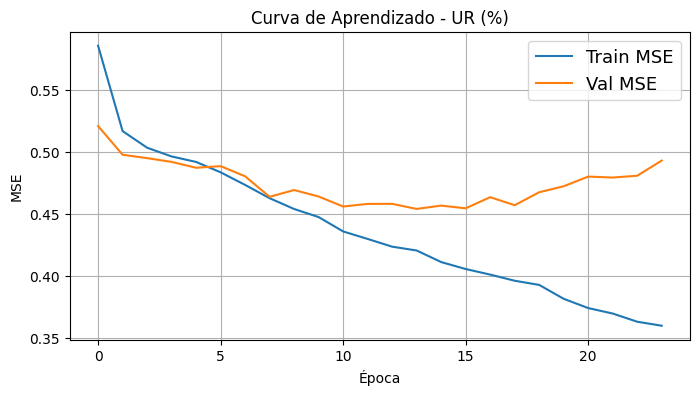


Resultados para UR (%):
RMSE: 6.5689
R²: 0.6059
Willmott: 0.8578
------------------------------------------------------------


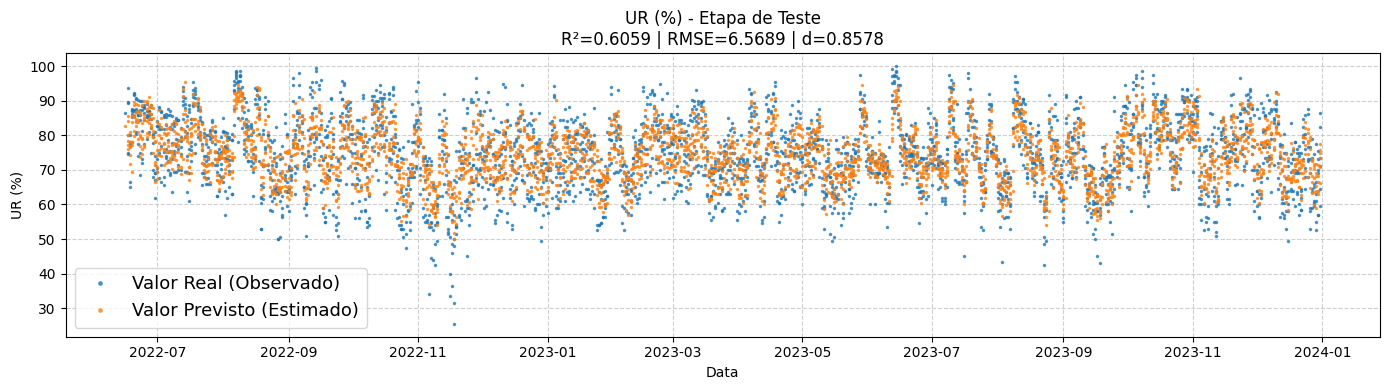

In [ ]:
resultados_metricas = []

# Loop principal
for var in variaveis_alvo:
  print('\n' + '=' * 60)
  print(f"▶ Treinamento para: {var}")
  print('=' * 60)

  df_model = df.copy()

  # Carregar Hiperparâmetros
  parametros = HIPERPARAMETROS_OTIMIZADOS[var]
  look_back = parametros['look_back']
  K_vmd = parametros['K_vmd']
  alpha = parametros['alpha']
  vmd_tol = parametros['vmd_tol']
  lr = parametros['lr']
  dropout = parametros['dropout']
  l2_reg = parametros['l2_reg']
  lstm_units_1 = parametros['lstm_units_1']
  lstm_units_2 = parametros['lstm_units_2']
  batch_size = parametros['batch_size']

  # Gerar Features (VMD)
  df_feat = gerar_features(df_model, var, parametros, window_vmd=None, progress=True)

  # Filtrar dinamicamente as colunas das IMFs geradas
  colunas_imfs = [c for c in df_feat.columns if c.startswith('IMF_')]

  # Seleção de features: variavel_alvo + (IMFs) + Sazonalidade
  colunas_finais = [var, 'sin_ano', 'cos_ano'] + colunas_imfs

  df_feat = df_feat[colunas_finais]

  # Dividir X e y
  y_raw = df_feat[[var]].values
  X_raw = df_feat.values

  # Split Temporal: train / val / test
  n = len(X_raw)
  n_test = int(n * 0.1)
  n_val = int(n * 0.1)
  n_train = n - n_val - n_test

  train_end = n_train
  val_end = n_train + n_val

  # Fatiamento temporal estrito
  X_train = X_raw[:train_end]
  y_train = y_raw[:train_end]

  X_val = X_raw[train_end:val_end]
  y_val = y_raw[train_end:val_end]

  X_test = X_raw[val_end:]
  y_test = y_raw[val_end:]

  # Normalizar os dados
  scaler_X = StandardScaler()
  scaler_y = StandardScaler()

  # FIT
  X_train_scaled = scaler_X.fit_transform(X_train)
  y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1))

  X_val_scaled = scaler_X.transform(X_val)
  y_val_scaled = scaler_y.transform(y_val.reshape(-1, 1))

  X_test_scaled = scaler_X.transform(X_test)
  y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1))

  # 5. Criar Sequências (3D para LSTM)
  X_lstm_train, y_lstm_train = create_sequences(X_train_scaled, y_train_scaled, look_back)
  X_lstm_val, y_lstm_val = create_sequences(X_val_scaled, y_val_scaled, look_back)
  X_lstm_test, y_lstm_test = create_sequences(X_test_scaled, y_test_scaled, look_back)

  # Limpeza de Memória
  del df_feat, X_raw, y_raw, X_train, y_train, X_val, y_val, X_test, y_test
  del X_train_scaled, y_train_scaled, X_val_scaled, y_val_scaled, X_test_scaled, y_test_scaled
  gc.collect()
  tf.keras.backend.clear_session()

  # Construção do Modelo
  model = Sequential([
      Input(shape=(X_lstm_train.shape[1], X_lstm_train.shape[2])),
      Bidirectional(LSTM(lstm_units_1, return_sequences=True, kernel_regularizer=l2(l2_reg))),
      Dropout(dropout),
      Bidirectional(LSTM(lstm_units_2, return_sequences=False, kernel_regularizer=l2(l2_reg))),
      Dropout(dropout),
      Dense(1, dtype='float32')
      ])

  model.compile(optimizer=Adam(learning_rate=lr, clipnorm=1.0), loss='mse')

  # Callbacks
  callbacks = [
      EarlyStopping(monitor='val_loss', patience=10, min_delta=1e-4, restore_best_weights=True, verbose=1),
      ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)
  ]

  # Treinamento
  hist = model.fit(
      X_lstm_train, y_lstm_train,
      epochs=200, batch_size=batch_size,
      validation_data=(X_lstm_val, y_lstm_val),
      callbacks=callbacks, verbose=1, shuffle=False
      )

  # Curva de Aprendizado
  plt.figure(figsize=(8, 4))
  plt.plot(hist.history['loss'], label='Train MSE')
  plt.plot(hist.history['val_loss'], label='Val MSE')
  plt.title(f"Curva de Aprendizado - {var}")
  plt.xlabel('Época')
  plt.ylabel('MSE')
  plt.legend(fontsize=13, loc='best', markerscale=1.6)
  plt.grid(True)
  plt.show()

  # --- Avaliação e Plotagem ---

  # Previsão
  y_pred_scaled = model.predict(X_lstm_test, verbose=0)

  # Inversão da Escala
  y_real = scaler_y.inverse_transform(y_lstm_test)
  y_pred = scaler_y.inverse_transform(y_pred_scaled)

  # Sem valores negativos
  if var == 'Rs (MJ/m²d)' or var == 'U2 (m/s)':
    y_pred = np.maximum(y_pred, 0)

  # Métricas
  metricas = avaliar_modelo(y_real, y_pred)
  metricas['Variavel'] = var
  resultados_metricas.append(metricas)

  # Print das métricas
  print(f"\nResultados para {var}:")
  print(f"RMSE: {metricas['RMSE']}")
  print(f"R²: {metricas['R²']}")
  print(f"Willmott: {metricas['Willmott']}")
  print('-' * 60)

  # Gráfico de Série Temporal
  dates_plot = df_model['Data'].iloc[-len(y_real):].values

  plt.figure(figsize=(14, 4))
  plt.plot(dates_plot, y_real, '.', label='Valor Real (Observado)', alpha=0.7, markersize=3)
  plt.plot(dates_plot, y_pred, '.', label='Valor Previsto (Estimado)', alpha=0.7, markersize=3)
  plt.title(f"{var} - Etapa de Teste\nR²={metricas['R²']} | RMSE={metricas['RMSE']} | d={metricas['Willmott']}")
  plt.xlabel('Data')
  plt.ylabel(var)
  plt.legend(fontsize=13, loc='best', markerscale=1.6)
  plt.grid(True, linestyle='--', alpha=0.6)
  plt.tight_layout()
  plt.show()

  # Limpeza final da iteração
  del model, y_real, y_pred, dates_plot
  tf.keras.backend.clear_session()
  gc.collect()

In [ ]:
# Criar DataFrame final com todos os resultados
df_resultados = pd.DataFrame(resultados_metricas)
print("\n=== RESUMO GERAL ===")
display(df_resultados)


=== RESUMO GERAL ===


,RMSE,R²,MAE,Willmott,MBE,Variavel
0,6.5689,0.6059,5.0486,0.8578,-0.0391,UR (%)
